# Project I ArtBench-10
**Student:** Filipe de Castro Oliveira 2024131032


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted (Colab).')
except ModuleNotFoundError:
    print('Ambiente local detectado: sem google.colab.')
    print('Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.')

Ambiente local detectado: sem google.colab.
Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.


In [2]:
from __future__ import annotations

import os
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths (Colab or local + Google Drive Desktop)
WORKSPACE_ROOT = Path.cwd()

def _is_usable_dir(p: Path) -> bool:
    try:
        return p.exists() and p.is_dir()
    except OSError:
        return False

if "google.colab" in sys.modules:
    PROJECT_ROOT = Path('/content/drive/MyDrive/MIACD - GAI')
else:
    # Opcional: setar no terminal -> $env:GOOGLE_DRIVE_ROOT='G:/My Drive/MIACD - GAI'
    _env_drive_root = os.environ.get('GOOGLE_DRIVE_ROOT', '').strip()
    _candidates = []
    if _env_drive_root:
        _candidates.append(Path(_env_drive_root).expanduser())
    _candidates += [
        Path('G:/My Drive/MIACD - GAI'),
        Path.home() / 'My Drive' / 'MIACD - GAI',
        Path.home() / 'Google Drive' / 'My Drive' / 'MIACD - GAI',
        WORKSPACE_ROOT / 'drive_outputs',
    ]
    PROJECT_ROOT = next((p for p in _candidates if _is_usable_dir(p)), _candidates[-1])

# Prefer scripts from workspace; fallback to drive root
SCRIPTS_DIR = WORKSPACE_ROOT / 'scripts'
if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    SCRIPTS_DIR = PROJECT_ROOT / 'scripts'

EXPORT_ROOT = PROJECT_ROOT / 'exported_data'
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        f"Could not resolve scripts folder. Tried: {WORKSPACE_ROOT / 'scripts'} and {PROJECT_ROOT / 'scripts'}"
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('WORKSPACE_ROOT =', WORKSPACE_ROOT)
print('PROJECT_ROOT   =', PROJECT_ROOT)
print('SCRIPTS_DIR    =', SCRIPTS_DIR)
print('EXPORT_ROOT    =', EXPORT_ROOT)

WORKSPACE_ROOT = c:\Users\User\source\repos\genai-project1
PROJECT_ROOT   = c:\Users\User\source\repos\genai-project1\drive_outputs
SCRIPTS_DIR    = c:\Users\User\source\repos\genai-project1\scripts
EXPORT_ROOT    = c:\Users\User\source\repos\genai-project1\drive_outputs\exported_data


In [4]:
import kagglehub
import os

def _is_artbench_root(p: Path) -> bool:
    p = Path(p)
    return (p / 'ArtBench-10.csv').exists() and (p / 'artbench-10-python').exists()

# 1) Try to reuse existing local dataset first
candidate_roots = []

if 'KAGGLE_ROOT' in globals() and KAGGLE_ROOT is not None:
    candidate_roots.append(Path(KAGGLE_ROOT))

if 'PROJECT_ROOT' in globals():
    candidate_roots += [
        Path(PROJECT_ROOT),
        Path(PROJECT_ROOT) / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'datasets' / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'data' / 'ArtBench-10',
    ]

if 'WORKSPACE_ROOT' in globals():
    candidate_roots += [
        Path(WORKSPACE_ROOT),
        Path(WORKSPACE_ROOT) / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'datasets' / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'data' / 'ArtBench-10',
    ]

KAGGLE_ROOT = next((p for p in candidate_roots if _is_artbench_root(p)), None)

if KAGGLE_ROOT is not None:
    print(f"Dataset já existe localmente. Pulando download.")
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")
else:
    # 2) Fallback: download using kagglehub
    print("Downloading ArtBench-10 dataset using kagglehub...")
    download_base_path = kagglehub.dataset_download("alexanderliao/artbench10")
    print(f"Dataset downloaded to: {download_base_path}")

    found_root = None
    for root, dirs, files in os.walk(download_base_path):
        if 'ArtBench-10.csv' in files and 'artbench-10-python' in dirs:
            found_root = Path(root)
            break

    if found_root is None:
        raise FileNotFoundError(
            "Could not find the 'ArtBench-10' root directory within the downloaded KaggleHub dataset."
        )

    KAGGLE_ROOT = found_root
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")

# This cell now reuses local data when available; otherwise it downloads.

c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2
Set KAGGLE_ROOT to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2


In [5]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [6]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [7]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

train_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),  # outputs [0,1]
])

val_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

transform = train_transform  # backward-compat alias


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=train_transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv`

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [8]:
import csv
import numpy as np
from torch.utils.data import DataLoader

# =========================
# Config
# =========================
INDEX_COLUMN = 'train_id_original'

VAL_FRACTION = 0.2
SPLIT_SEED = 42

# Resolve training_20_percent.csv with robust fallbacks
_csv_candidates = [
    WORKSPACE_ROOT / 'scripts' / 'training_20_percent.csv',
    PROJECT_ROOT / 'scripts' / 'training_20_percent.csv',
    SCRIPTS_DIR / 'training_20_percent.csv',
]
TRAINING_CSV_PATH = next((p for p in _csv_candidates if p.exists()), _csv_candidates[0])
print(f"Using TRAINING_CSV_PATH: {TRAINING_CSV_PATH}")

# =========================
# Load IDs
# =========================
def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training_20_percent.csv not found: {csv_path}\n"
            f"Tried candidates: {_csv_candidates}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)

print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])


# =========================
# Split train / val
# =========================
def split_indices(indices, val_fraction=0.2, seed=42):
    indices = np.array(indices)
    rng = np.random.RandomState(seed)
    shuffled = indices.copy()
    rng.shuffle(shuffled)

    n_val = int(round(len(shuffled) * val_fraction))
    val_ids = shuffled[:n_val].tolist()
    train_ids = shuffled[n_val:].tolist()
    return train_ids, val_ids


train_ids_split, val_ids_split = split_indices(
    train_ids_from_csv,
    val_fraction=VAL_FRACTION,
    seed=SPLIT_SEED,
)

print("Train ids:", len(train_ids_split))
print("Val ids  :", len(val_ids_split))


# =========================
# Datasets
# =========================
train_ds_from_csv = HFDatasetTorch(
    train_hf,
    transform=transform,
    indices=train_ids_split
)

val_ds_from_csv = HFDatasetTorch(
    train_hf,
    transform=transform,
    indices=val_ids_split
)


# =========================
# DataLoaders
# =========================
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader_from_csv = DataLoader(
    val_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Train dataset length:', len(train_ds_from_csv))
print('Val dataset length  :', len(val_ds_from_csv))
print('Train batches       :', len(train_loader_from_csv))
print('Val batches         :', len(val_loader_from_csv))

Using TRAINING_CSV_PATH: c:\Users\User\source\repos\genai-project1\scripts\training_20_percent.csv
Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Train ids: 8000
Val ids  : 2000
Train dataset length: 8000
Val dataset length  : 2000
Train batches       : 125
Val batches         : 32


## Visualize a sample grid

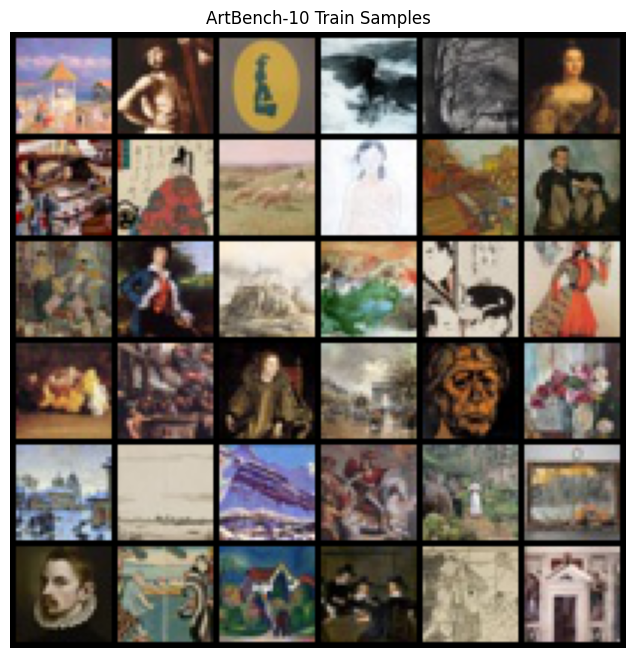

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [9]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [10]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = PROJECT_ROOT / 'exported_data' # Changed to export to Drive
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)

Exported 500 images to: c:\Users\User\source\repos\genai-project1\drive_outputs\exported_data\train_subset\images
Metadata CSV: c:\Users\User\source\repos\genai-project1\drive_outputs\exported_data\train_subset\metadata.csv


---
# VAE
---


In [11]:
class Encoder(nn.Module):
    """Encoder maps images to latent space parameters (mu, log_var)."""

    def __init__(
        self,
        img_channels: int = 3,
        latent_dim: int = 128,
        hidden_dims: list = None,
        image_size: int = 32,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256]

        self.hidden_dims = list(hidden_dims)
        self.image_size = int(image_size)
        self.latent_dim = latent_dim

        # Build encoder CNN
        modules = []
        in_channels = img_channels

        for h_dim in self.hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, h_dim, kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU(0.2, inplace=True),
                )
            )
            in_channels = h_dim

        self.encoder_cnn = nn.Sequential(*modules)

        # Calculate final feature map size
        # For each stride-2 layer: size = size // 2
        self.feature_map_hw = self.image_size // (2 ** len(self.hidden_dims))

        if self.feature_map_hw < 1:
            raise ValueError(
                f"image_size={self.image_size} too small for "
                f"{len(self.hidden_dims)} downsampling layers"
            )

        final_feature_map_size = self.hidden_dims[-1] * self.feature_map_hw**2

        # Latent parameters
        self.fc_mu = nn.Linear(final_feature_map_size, latent_dim)
        self.fc_log_var = nn.Linear(final_feature_map_size, latent_dim)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Encode image to latent parameters.

        Args:
            x: Input tensor (B, C, H, W)

        Returns:
            mu: Mean of latent distribution (B, latent_dim)
            log_var: Log variance of latent distribution (B, latent_dim)
        """
        x = self.encoder_cnn(x)
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        return mu, log_var


In [12]:
class Decoder(nn.Module):
    """Decoder reconstructs images from latent vectors."""

    def __init__(
        self,
        img_channels: int = 3,
        latent_dim: int = 128,
        hidden_dims: list = None,
        image_size: int = 32,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256]

        self.hidden_dims = list(hidden_dims)
        self.image_size = int(image_size)
        self.latent_dim = latent_dim

        # Calculate initial feature map size (same as encoder output)
        self.feature_map_hw = self.image_size // (2 ** len(self.hidden_dims))

        if self.feature_map_hw < 1:
            raise ValueError(
                f"image_size={self.image_size} too small for "
                f"{len(self.hidden_dims)} upsampling layers"
            )

        self.init_channels = self.hidden_dims[-1]

        # Project latent vector to initial feature map
        init_feature_size = self.init_channels * self.feature_map_hw**2
        self.decoder_input = nn.Linear(latent_dim, init_feature_size)

        # Build decoder CNN (reverse order of hidden dims)
        modules = []
        rev_hidden_dims = self.hidden_dims[::-1]

        # Transposed conv layers
        for i in range(len(rev_hidden_dims) - 1):
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        rev_hidden_dims[i],
                        rev_hidden_dims[i + 1],
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=1,
                    ),
                    nn.BatchNorm2d(rev_hidden_dims[i + 1]),
                    nn.LeakyReLU(0.2, inplace=True),
                )
            )

        # Final layer to output channels
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(
                    rev_hidden_dims[-1],
                    img_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.Sigmoid(),  # Output in [0, 1] range
            )
        )

        self.decoder_cnn = nn.Sequential(*modules)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Decode latent vector to image.

        Args:
            z: Latent tensor (B, latent_dim)

        Returns:
            reconstruction: Reconstructed image (B, C, H, W)
        """
        x = self.decoder_input(z)
        x = x.view(-1, self.init_channels, self.feature_map_hw, self.feature_map_hw)
        x = self.decoder_cnn(x)
        return x


In [13]:
class VAE(nn.Module):
    """Variational Autoencoder combining Encoder and Decoder."""

    def __init__(
        self,
        img_channels: int = 3,
        latent_dim: int = 128,
        hidden_dims: list = None,
        image_size: int = 32,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256]

        self.latent_dim = latent_dim

        self.encoder = Encoder(
            img_channels=img_channels,
            latent_dim=latent_dim,
            hidden_dims=hidden_dims,
            image_size=image_size,
        )

        self.decoder = Decoder(
            img_channels=img_channels,
            latent_dim=latent_dim,
            hidden_dims=hidden_dims,
            image_size=image_size,
        )

    def reparameterize(
        self, mu: torch.Tensor, log_var: torch.Tensor
    ) -> torch.Tensor:
        """
        Sample latent vector using reparameterization trick.

        Args:
            mu: Mean of latent distribution (B, latent_dim)
            log_var: Log variance of latent distribution (B, latent_dim)

        Returns:
            z: Sampled latent vector (B, latent_dim)
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std, device=mu.device)
        z = mu + eps * std
        return z

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Full VAE forward pass.

        Args:
            x: Input image (B, C, H, W)

        Returns:
            reconstruction: Reconstructed image (B, C, H, W)
            mu: Latent mean (B, latent_dim)
            log_var: Latent log variance (B, latent_dim)
        """
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        reconstruction = self.decoder(z)
        return reconstruction, mu, log_var

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Encode image to latent parameters."""
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode latent vector to image."""
        return self.decoder(z)

    def sample(self, num_samples: int, device: str = "cpu") -> torch.Tensor:
        """Generate samples from standard normal distribution."""
        z = torch.randn(num_samples, self.latent_dim, device=device)
        return self.decoder(z)


In [14]:
def vae_loss(
    reconstruction: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    log_var: torch.Tensor,
    beta: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Compute VAE loss = reconstruction loss + beta * KL divergence.

    Args:
        reconstruction: Reconstructed image (B, C, H, W) in [0,1]
        x: Original image (B, C, H, W) in [0,1]
        mu: Latent mean (B, latent_dim)
        log_var: Latent log variance (B, latent_dim)
        beta: Weight for KL divergence term

    Returns:
        loss: Total VAE loss
        recon_loss: Reconstruction loss (BCE)
        kl_loss: KL divergence loss
    """
    # Reconstruction loss (Binary Cross-Entropy for [0,1] normalized images)
    recon_loss = F.binary_cross_entropy(reconstruction, x, reduction="mean")

    # KL divergence: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    # Averaged over batch dimension
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

    # Total loss
    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss


def compute_beta_warmup(epoch: int, warmup_epochs: int, beta_max: float) -> float:
    """
    Compute KL divergence weight during warmup phase.

    Linearly increases from 0 to beta_max over warmup_epochs.

    Args:
        epoch: Current epoch (0-indexed)
        warmup_epochs: Number of warmup epochs
        beta_max: Maximum beta value

    Returns:
        beta: Current beta value
    """
    if epoch < warmup_epochs:
        return (epoch / warmup_epochs) * beta_max
    return beta_max

## Train VAE Model Baseline

Device: cuda
Train size: 8000 | Val size: 2000
Batch size: 64
Latent dim: 256

Starting run: vae_ldim256_ep100_seed42
Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\vae_ldim256_ep100_seed42
[ldim= 256] Epoch  1/100 | beta=0.000 | train: loss=0.6173, recon=0.6173, kl=3.0292 | val: loss=0.5991, recon=0.5991, kl=4.0420
[ldim= 256] Epoch  2/100 | beta=0.010 | train: loss=0.6024, recon=0.5971, kl=0.5330 | val: loss=0.6005, recon=0.5963, kl=0.4214
[ldim= 256] Epoch  3/100 | beta=0.020 | train: loss=0.5981, recon=0.5919, kl=0.3081 | val: loss=0.5975, recon=0.5910, kl=0.3233
[ldim= 256] Epoch  4/100 | beta=0.030 | train: loss=0.5947, recon=0.5873, kl=0.2475 | val: loss=0.5947, recon=0.5878, kl=0.2301
[ldim= 256] Epoch  5/100 | beta=0.040 | train: loss=0.5935, recon=0.5855, kl=0.1995 | val: loss=0.5946, recon=0.5869, kl=0.1924
[ldim= 256] Epoch  6/100 | beta=0.050 | train: loss=0.5937, recon=0.5851, kl=0.1722 | val: loss=0.5954, recon=0.5869, kl=0.1714
[ldim= 256] Epoch  

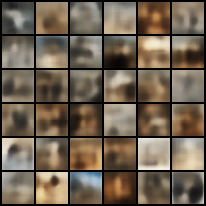

[ldim= 256] Epoch 25/100 | beta=0.100 | train: loss=0.5941, recon=0.5830, kl=0.1111 | val: loss=0.5970, recon=0.5863, kl=0.1075
[ldim= 256] Epoch 26/100 | beta=0.100 | train: loss=0.5941, recon=0.5830, kl=0.1112 | val: loss=0.5965, recon=0.5854, kl=0.1108
[ldim= 256] Epoch 27/100 | beta=0.100 | train: loss=0.5940, recon=0.5829, kl=0.1117 | val: loss=0.5965, recon=0.5856, kl=0.1085
[ldim= 256] Epoch 28/100 | beta=0.100 | train: loss=0.5942, recon=0.5831, kl=0.1111 | val: loss=0.5965, recon=0.5857, kl=0.1080
[ldim= 256] Epoch 29/100 | beta=0.100 | train: loss=0.5938, recon=0.5827, kl=0.1117 | val: loss=0.5967, recon=0.5852, kl=0.1144
[ldim= 256] Epoch 30/100 | beta=0.100 | train: loss=0.5938, recon=0.5827, kl=0.1116 | val: loss=0.5965, recon=0.5858, kl=0.1069
[ldim= 256] Epoch 31/100 | beta=0.100 | train: loss=0.5938, recon=0.5827, kl=0.1111 | val: loss=0.5962, recon=0.5851, kl=0.1103
[ldim= 256] Epoch 32/100 | beta=0.100 | train: loss=0.5938, recon=0.5827, kl=0.1114 | val: loss=0.5961, 

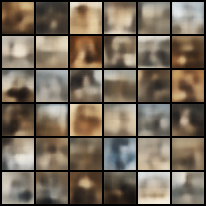

[ldim= 256] Epoch 50/100 | beta=0.100 | train: loss=0.5929, recon=0.5817, kl=0.1126 | val: loss=0.5955, recon=0.5846, kl=0.1092
[ldim= 256] Epoch 51/100 | beta=0.100 | train: loss=0.5927, recon=0.5814, kl=0.1127 | val: loss=0.5954, recon=0.5842, kl=0.1118
[ldim= 256] Epoch 52/100 | beta=0.100 | train: loss=0.5926, recon=0.5814, kl=0.1126 | val: loss=0.5957, recon=0.5846, kl=0.1115
[ldim= 256] Epoch 53/100 | beta=0.100 | train: loss=0.5927, recon=0.5814, kl=0.1124 | val: loss=0.5955, recon=0.5841, kl=0.1133
[ldim= 256] Epoch 54/100 | beta=0.100 | train: loss=0.5928, recon=0.5815, kl=0.1131 | val: loss=0.5954, recon=0.5844, kl=0.1107
[ldim= 256] Epoch 55/100 | beta=0.100 | train: loss=0.5925, recon=0.5812, kl=0.1127 | val: loss=0.5954, recon=0.5842, kl=0.1114
[ldim= 256] Epoch 56/100 | beta=0.100 | train: loss=0.5924, recon=0.5811, kl=0.1126 | val: loss=0.5953, recon=0.5840, kl=0.1134
[ldim= 256] Epoch 57/100 | beta=0.100 | train: loss=0.5926, recon=0.5813, kl=0.1127 | val: loss=0.5954, 

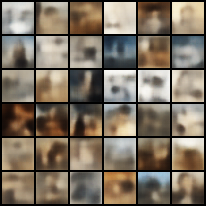

[ldim= 256] Epoch 75/100 | beta=0.100 | train: loss=0.5923, recon=0.5810, kl=0.1132 | val: loss=0.5951, recon=0.5838, kl=0.1124
[ldim= 256] Epoch 76/100 | beta=0.100 | train: loss=0.5918, recon=0.5805, kl=0.1137 | val: loss=0.5949, recon=0.5836, kl=0.1136
[ldim= 256] Epoch 77/100 | beta=0.100 | train: loss=0.5920, recon=0.5807, kl=0.1129 | val: loss=0.5949, recon=0.5838, kl=0.1111
[ldim= 256] Epoch 78/100 | beta=0.100 | train: loss=0.5919, recon=0.5805, kl=0.1139 | val: loss=0.5948, recon=0.5837, kl=0.1104
[ldim= 256] Epoch 79/100 | beta=0.100 | train: loss=0.5920, recon=0.5807, kl=0.1137 | val: loss=0.5948, recon=0.5835, kl=0.1127
[ldim= 256] Epoch 80/100 | beta=0.100 | train: loss=0.5918, recon=0.5805, kl=0.1131 | val: loss=0.5949, recon=0.5840, kl=0.1088
[ldim= 256] Epoch 81/100 | beta=0.100 | train: loss=0.5919, recon=0.5805, kl=0.1134 | val: loss=0.5948, recon=0.5836, kl=0.1116
[ldim= 256] Epoch 82/100 | beta=0.100 | train: loss=0.5919, recon=0.5805, kl=0.1135 | val: loss=0.5948, 

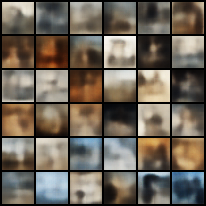

[ldim= 256] Epoch 100/100 | beta=0.100 | train: loss=0.5918, recon=0.5804, kl=0.1136 | val: loss=0.5946, recon=0.5834, kl=0.1120
----------------------------------------------------------------------------------------------------
Finished vae_ldim256_ep100_seed42 | best_val_loss=0.5946 | best_epoch=93 | best_val_recon=0.5834 | best_val_kl=0.1115 | time=13.4 min
----------------------------------------------------------------------------------------------------

VAE TRAINING FINISHED
latent_dim=256 | best_val_loss=0.5946 | best_epoch=93 | dir=c:\Users\User\source\repos\genai-project1\drive_outputs\runs\vae_ldim256_ep100_seed42

Summary CSV saved to: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\summary_vae.csv


In [26]:
import os
import csv
import json
import gc
import time
from pathlib import Path

import torch
import torch.optim as optim
from torchvision.utils import save_image
from IPython.display import display as ipy_display, Image as IPyImage

# =========================
# Config
# =========================
latent_dim = 256

img_channels = 3
image_size = IMAGE_SIZE
hidden_dims = [32, 64, 128, 256]

learning_rate = 1e-3
weight_decay = 0.0
num_epochs = 100

beta_max = 0.1
warmup_epochs = 10

seed = 42
model_family = "vae"

# =========================
# Paths
# =========================
base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
base_runs_dir.mkdir(parents=True, exist_ok=True)

summary_csv_path = base_runs_dir / "summary_vae.csv"

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 100)
print(f"Device: {device}")
print(f"Train size: {len(train_loader_from_csv.dataset)} | Val size: {len(val_loader_from_csv.dataset)}")
print(f"Batch size: {train_loader_from_csv.batch_size}")
print(f"Latent dim: {latent_dim}")
print("=" * 100)


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def train_vae_for_latent_dim(latent_dim: int):
    run_name = f"vae_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
    run_dir = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    metrics_csv_path = run_dir / "metrics.csv"
    config_json_path = run_dir / "config.json"
    best_ckpt_path = run_dir / "best_model.pt"
    final_ckpt_path = run_dir / "final_model.pt"
    samples_dir = run_dir / "samples"
    samples_dir.mkdir(parents=True, exist_ok=True)

    config = {
        "run_name": run_name,
        "model_family": model_family,
        "seed": seed,
        "img_channels": img_channels,
        "image_size": image_size,
        "latent_dim": latent_dim,
        "hidden_dims": hidden_dims,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "num_epochs": num_epochs,
        "beta_max": beta_max,
        "warmup_epochs": warmup_epochs,
        "train_size": len(train_loader_from_csv.dataset),
        "val_size": len(val_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
    }
    save_json(config, config_json_path)

    vae_model = VAE(
        img_channels=img_channels,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        image_size=image_size,
    ).to(device)

    optimizer = optim.Adam(
        vae_model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

    fieldnames = [
        "epoch",
        "beta",
        "train_loss",
        "train_recon",
        "train_kl",
        "val_loss",
        "val_recon",
        "val_kl",
    ]

    with open(metrics_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

    best_val_loss = float("inf")
    best_epoch = -1
    best_val_recon = None
    best_val_kl = None

    print("\n" + "=" * 100)
    print(f"Starting run: {run_name}")
    print(f"Run dir: {run_dir}")
    print("=" * 100)

    start_time = time.time()

    for epoch in range(num_epochs):
        beta = compute_beta_warmup(epoch, warmup_epochs, beta_max)

        # ---- TRAIN ----
        vae_model.train()
        train_loss_sum = 0.0
        train_recon_sum = 0.0
        train_kl_sum = 0.0
        train_num_batches = 0

        for batch in train_loader_from_csv:
            x = batch[0].to(device, non_blocking=True)

            optimizer.zero_grad()

            reconstruction, mu, log_var = vae_model(x)
            loss, recon_loss, kl_loss = vae_loss(
                reconstruction, x, mu, log_var, beta=beta
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae_model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_sum += loss.item()
            train_recon_sum += recon_loss.item()
            train_kl_sum += kl_loss.item()
            train_num_batches += 1

        train_loss = train_loss_sum / train_num_batches
        train_recon = train_recon_sum / train_num_batches
        train_kl = train_kl_sum / train_num_batches

        # ---- VALIDATION ----
        vae_model.eval()
        val_loss_sum = 0.0
        val_recon_sum = 0.0
        val_kl_sum = 0.0
        val_num_batches = 0

        with torch.no_grad():
            for batch in val_loader_from_csv:
                x = batch[0].to(device, non_blocking=True)

                reconstruction, mu, log_var = vae_model(x)
                loss, recon_loss, kl_loss = vae_loss(
                    reconstruction, x, mu, log_var, beta=beta
                )

                val_loss_sum += loss.item()
                val_recon_sum += recon_loss.item()
                val_kl_sum += kl_loss.item()
                val_num_batches += 1

        val_loss = val_loss_sum / val_num_batches
        val_recon = val_recon_sum / val_num_batches
        val_kl = val_kl_sum / val_num_batches

        scheduler.step()

        row = {
            "epoch": epoch + 1,
            "beta": beta,
            "train_loss": train_loss,
            "train_recon": train_recon,
            "train_kl": train_kl,
            "val_loss": val_loss,
            "val_recon": val_recon,
            "val_kl": val_kl,
        }

        with open(metrics_csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writerow(row)

        # ---- Save best ----
        if (epoch + 1) > warmup_epochs and val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_val_recon = val_recon
            best_val_kl = val_kl

            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": vae_model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_loss": best_val_loss,
                    "best_val_recon": best_val_recon,
                    "best_val_kl": best_val_kl,
                    "config": config,
                },
                best_ckpt_path,
            )

        if (epoch + 1) % 25 == 0:
            with torch.no_grad():
                z = torch.randn(36, latent_dim, device=device)
                samples = vae_model.decode(z).clamp(0.0, 1.0)
            _sp = samples_dir / f"samples_epoch_{epoch+1:03d}.png"
            save_image(samples, _sp, nrow=6)
            print(f"VAE samples — epoch {epoch+1}")
            ipy_display(IPyImage(str(_sp), width=500))

        print(
            f"[ldim={latent_dim:>4}] "
            f"Epoch {epoch+1:>2}/{num_epochs} | "
            f"beta={beta:.3f} | "
            f"train: loss={train_loss:.4f}, recon={train_recon:.4f}, kl={train_kl:.4f} | "
            f"val: loss={val_loss:.4f}, recon={val_recon:.4f}, kl={val_kl:.4f}"
        )

    total_time_sec = time.time() - start_time

    # ---- Save final checkpoint ----
    torch.save(
        {
            "epoch": num_epochs,
            "model_state_dict": vae_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "best_val_recon": best_val_recon,
            "best_val_kl": best_val_kl,
            "config": config,
        },
        final_ckpt_path,
    )

    summary_row = {
        "run_name": run_name,
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_recon": best_val_recon,
        "best_val_kl": best_val_kl,
        "train_size": len(train_loader_from_csv.dataset),
        "val_size": len(val_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
        "beta_max": beta_max,
        "warmup_epochs": warmup_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "run_dir": str(run_dir),
        "best_ckpt_path": str(best_ckpt_path),
        "final_ckpt_path": str(final_ckpt_path),
        "time_sec": total_time_sec,
        "status": "ok",
    }

    print("-" * 100)
    print(
        f"Finished {run_name} | "
        f"best_val_loss={best_val_loss:.4f} | "
        f"best_epoch={best_epoch} | "
        f"best_val_recon={best_val_recon:.4f} | "
        f"best_val_kl={best_val_kl:.4f} | "
        f"time={total_time_sec/60:.1f} min"
    )
    print("-" * 100)

    return summary_row


# =========================
# Run all latent dims
# =========================
summary_fieldnames = [
    "run_name",
    "latent_dim",
    "num_epochs",
    "best_epoch",
    "best_val_loss",
    "best_val_recon",
    "best_val_kl",
    "train_size",
    "val_size",
    "batch_size",
    "beta_max",
    "warmup_epochs",
    "learning_rate",
    "weight_decay",
    "run_dir",
    "best_ckpt_path",
    "final_ckpt_path",
    "time_sec",
    "status",
]

all_results = []

with open(summary_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writeheader()

try:
    result = train_vae_for_latent_dim(latent_dim)

except RuntimeError as e:
    result = {
        "run_name": f"vae_ldim{latent_dim}_ep{num_epochs}_seed{seed}",
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "best_epoch": None,
        "best_val_loss": None,
        "best_val_recon": None,
        "best_val_kl": None,
        "train_size": len(train_loader_from_csv.dataset),
        "val_size": len(val_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
        "beta_max": beta_max,
        "warmup_epochs": warmup_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "run_dir": "",
        "best_ckpt_path": "",
        "final_ckpt_path": "",
        "time_sec": None,
        "status": f"runtime_error: {str(e)}",
    }
    print("\n" + "!" * 100)
    print(f"Run failed for latent_dim={latent_dim}")
    print(str(e))
    print("!" * 100)

with open(summary_csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writerow(result)

all_results.append(result)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =========================
# Final ranking print
# =========================
ok_results = [r for r in all_results if r["status"] == "ok" and r["best_val_loss"] is not None]
ok_results = sorted(ok_results, key=lambda x: x["best_val_loss"])

print("\n" + "=" * 100)
print("VAE TRAINING FINISHED")
print("=" * 100)

if all_results and all_results[0]["status"] == "ok":
    r = all_results[0]
    print(f"latent_dim={r['latent_dim']} | best_val_loss={r['best_val_loss']:.4f} | best_epoch={r['best_epoch']} | dir={r['run_dir']}")
else:
    print("Training failed.")

print(f"\nSummary CSV saved to: {summary_csv_path}")

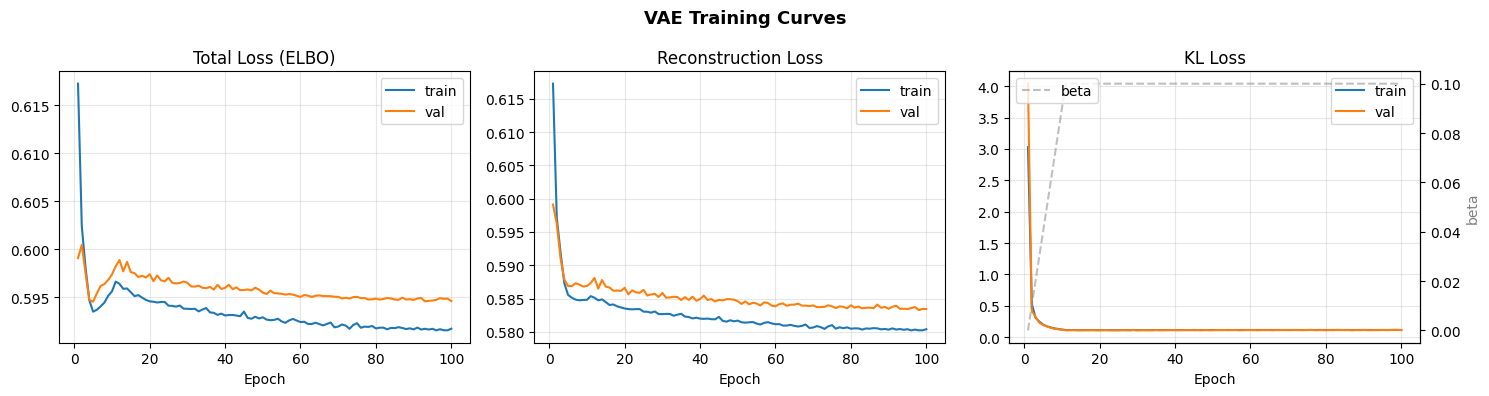

In [27]:
# VAE — Loss Curves
import csv
import matplotlib.pyplot as plt
from pathlib import Path

_runs = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
_metrics = _runs / "vae_ldim256_ep100_seed42" / "metrics.csv"

if _metrics.exists():
    ep, tr_loss, vl_loss, tr_recon, vl_recon, tr_kl, vl_kl, betas = ([] for _ in range(8))
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            tr_loss.append(float(row["train_loss"]));  vl_loss.append(float(row["val_loss"]))
            tr_recon.append(float(row["train_recon"])); vl_recon.append(float(row["val_recon"]))
            tr_kl.append(float(row["train_kl"]));       vl_kl.append(float(row["val_kl"]))
            betas.append(float(row["beta"]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, tr, vl, title in zip(axes,
        [tr_loss, tr_recon, tr_kl],
        [vl_loss, vl_recon, vl_kl],
        ["Total Loss (ELBO)", "Reconstruction Loss", "KL Loss"]):
        ax.plot(ep, tr, label="train")
        ax.plot(ep, vl, label="val")
        ax.set_title(title); ax.set_xlabel("Epoch")
        ax.legend(); ax.grid(True, alpha=0.3)

    # add beta on KL subplot secondary axis
    ax2 = axes[2].twinx()
    ax2.plot(ep, betas, color="gray", linestyle="--", alpha=0.5, label="beta")
    ax2.set_ylabel("beta", color="gray"); ax2.legend(loc="upper left")

    fig.suptitle("VAE Training Curves", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


Lessons Learned so far:
- Trained with latend_dim = 32, 64, 128, 256, 512, 1024
- Greater the latent_dim => better results only to a certain point


## Sample from VAE

Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\vae_ldim256_ep100_seed42
Loaded epoch: 93 | Best val_loss: 0.5946


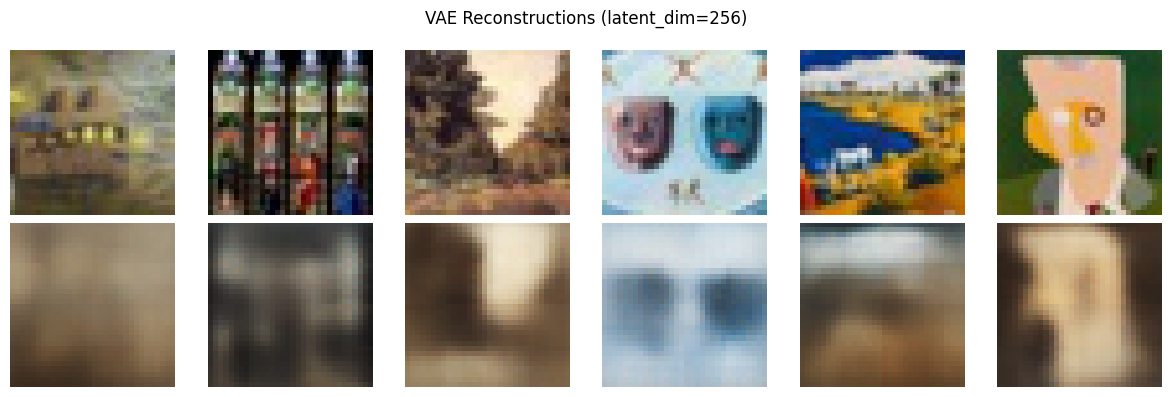

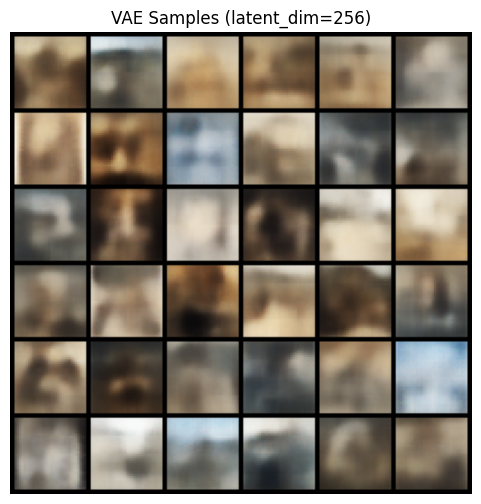

In [28]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from pathlib import Path

base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 256
num_epochs = 100
seed = 42

def show_image_grid(images, n_images=36, nrow=6, title="Image Grid"):
    images = images[:n_images].detach().cpu()
    grid = make_grid(images, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(np_img)
    plt.axis("off")
    plt.title(title)
    plt.show()


def show_reconstructions(model, x, title, n_show=6):
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(x)
    plt.figure(figsize=(2 * n_show, 4))
    for i in range(n_show):
        plt.subplot(2, n_show, i + 1)
        plt.imshow(x[i].detach().cpu().permute(1, 2, 0).numpy())
        plt.axis("off")
        if i == 0: plt.ylabel("Orig")
        plt.subplot(2, n_show, n_show + i + 1)
        plt.imshow(recon[i].detach().cpu().permute(1, 2, 0).numpy())
        plt.axis("off")
        if i == 0: plt.ylabel("Recon")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


x_val, _, _ = next(iter(val_loader_from_csv))
x_val = x_val.to(device)

run_name = f"vae_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
run_dir = base_runs_dir / run_name
best_ckpt_path = run_dir / "best_model.pt"

print(f"Run dir: {run_dir}")

if not best_ckpt_path.exists():
    print(f"Checkpoint not found: {best_ckpt_path}")
else:
    vae_model = VAE(
        img_channels=3,
        latent_dim=latent_dim,
        hidden_dims=[32, 64, 128, 256],
        image_size=IMAGE_SIZE,
    ).to(device)

    checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
    vae_model.load_state_dict(checkpoint["model_state_dict"])
    vae_model.eval()

    print(f"Loaded epoch: {checkpoint['epoch']} | Best val_loss: {checkpoint['best_val_loss']:.4f}")

    show_reconstructions(vae_model, x_val, title=f"VAE Reconstructions (latent_dim={latent_dim})", n_show=6)

    with torch.no_grad():
        samples = vae_model.sample(36, device=device)

    show_image_grid(samples, n_images=36, nrow=6, title=f"VAE Samples (latent_dim={latent_dim})")


---
# DCGAN
---

In [15]:
import torch
import torch.nn as nn


class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int = 128,
        img_channels: int = 3,
        img_size: int = 32,
        hidden_dims: list[int] = [32, 64, 128, 256],
    ):
        super().__init__()

        self.latent_dim = latent_dim
        self.img_size = img_size
        self.img_channels = img_channels
        self.hidden_dims = hidden_dims

        # For img_size=32 and 4 upsampling blocks:
        # 32 -> 16 -> 8 -> 4 -> 2 (encoder view)
        # so generator starts from 2x2 and upsamples back to 32x32
        self.initial_spatial_dim = img_size // (2 ** len(hidden_dims))
        if self.initial_spatial_dim < 1:
            raise ValueError(
                f"img_size={img_size} too small for {len(hidden_dims)} upsampling layers"
            )

        self.initial_channels = hidden_dims[-1]

        # Project z -> initial feature map
        self.initial_projection = nn.Linear(
            latent_dim,
            self.initial_channels * (self.initial_spatial_dim ** 2)
        )

        modules = []
        reversed_hidden_dims = hidden_dims[::-1]  # e.g. [256, 128, 64, 32]

        in_channels = reversed_hidden_dims[0]
        for i in range(len(reversed_hidden_dims) - 1):
            out_channels = reversed_hidden_dims[i + 1]
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        in_channels,
                        out_channels,
                        kernel_size=4,
                        stride=2,
                        padding=1,
                        bias=False,
                    ),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(True),
                )
            )
            in_channels = out_channels

        # Final upsampling to image
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(
                    in_channels,
                    img_channels,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    bias=False,
                ),
                nn.Tanh(),  # output in [-1, 1]
            )
        )

        self.main = nn.Sequential(*modules)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.initial_projection(z)
        x = x.view(
            -1,
            self.initial_channels,
            self.initial_spatial_dim,
            self.initial_spatial_dim,
        )
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] = [32, 64, 128, 256],
    ):
        super().__init__()

        modules = []

        # First block: no BatchNorm (standard DCGAN practice)
        modules.append(
            nn.Sequential(
                nn.Conv2d(
                    img_channels,
                    hidden_dims[0],
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    bias=False,
                ),
                nn.LeakyReLU(0.2, inplace=True),
            )
        )

        in_channels = hidden_dims[0]

        for i in range(1, len(hidden_dims)):
            out_channels = hidden_dims[i]
            modules.append(
                nn.Sequential(
                    nn.Conv2d(
                        in_channels,
                        out_channels,
                        kernel_size=4,
                        stride=2,
                        padding=1,
                        bias=False,
                    ),
                    nn.BatchNorm2d(out_channels),
                    nn.LeakyReLU(0.2, inplace=True),
                )
            )
            in_channels = out_channels

        self.main = nn.Sequential(*modules)

        # For 32x32 with 4 downsampling blocks:
        # 32 -> 16 -> 8 -> 4 -> 2
        # final 2x2 -> 1x1 scalar
        self.final_conv = nn.Conv2d(
            in_channels,
            1,
            kernel_size=2,
            stride=1,
            padding=0,
            bias=False,
        )

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        x = self.main(img)
        x = self.final_conv(x)
        return x.view(-1)  # raw logits


def dcgan_weights_init(m):
    """
    DCGAN-style weight initialization.
    """
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)

## Train DCGAN Model

train_loader_gan / val_loader_gan not found. Rebuilding them now...
Device: cuda
Train size: 8000 | Val size: 2000
Batch size: 64
Latent dim: 256

Starting run: dcgan_ldim256_ep100_seed42
Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\dcgan_ldim256_ep100_seed42
[ldim= 256] Epoch  1/100 | D_loss=0.2728 | G_loss=5.6508 | D(real)=0.9036 | D(fake)=0.0317
[ldim= 256] Epoch  2/100 | D_loss=0.6260 | G_loss=3.7923 | D(real)=0.8018 | D(fake)=0.0696
[ldim= 256] Epoch  3/100 | D_loss=1.0519 | G_loss=2.3979 | D(real)=0.6547 | D(fake)=0.1436
[ldim= 256] Epoch  4/100 | D_loss=0.6926 | G_loss=2.9723 | D(real)=0.7583 | D(fake)=0.0873
[ldim= 256] Epoch  5/100 | D_loss=0.6787 | G_loss=3.4217 | D(real)=0.7592 | D(fake)=0.0605
[ldim= 256] Epoch  6/100 | D_loss=0.4849 | G_loss=3.9822 | D(real)=0.8243 | D(fake)=0.0395
[ldim= 256] Epoch  7/100 | D_loss=0.8705 | G_loss=3.6198 | D(real)=0.7506 | D(fake)=0.0722
[ldim= 256] Epoch  8/100 | D_loss=0.7437 | G_loss=3.7141 | D(real)=0.7514 | D(

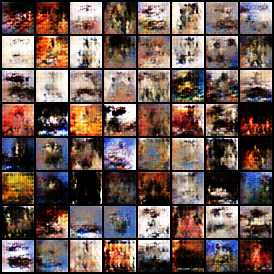

[ldim= 256] Epoch 25/100 | D_loss=0.6795 | G_loss=4.0649 | D(real)=0.7798 | D(fake)=0.0722
[ldim= 256] Epoch 26/100 | D_loss=0.7081 | G_loss=4.1998 | D(real)=0.7712 | D(fake)=0.0693
[ldim= 256] Epoch 27/100 | D_loss=0.7221 | G_loss=4.3017 | D(real)=0.7993 | D(fake)=0.0838
[ldim= 256] Epoch 28/100 | D_loss=0.8157 | G_loss=4.0517 | D(real)=0.7687 | D(fake)=0.1067
[ldim= 256] Epoch 29/100 | D_loss=0.8461 | G_loss=3.8486 | D(real)=0.7648 | D(fake)=0.1014
[ldim= 256] Epoch 30/100 | D_loss=0.7961 | G_loss=4.1214 | D(real)=0.7926 | D(fake)=0.0983
[ldim= 256] Epoch 31/100 | D_loss=0.5674 | G_loss=5.0165 | D(real)=0.8343 | D(fake)=0.0660
[ldim= 256] Epoch 32/100 | D_loss=0.8542 | G_loss=4.0210 | D(real)=0.7842 | D(fake)=0.1161
[ldim= 256] Epoch 33/100 | D_loss=1.0169 | G_loss=4.0554 | D(real)=0.7772 | D(fake)=0.1236
[ldim= 256] Epoch 34/100 | D_loss=0.8750 | G_loss=4.0557 | D(real)=0.7754 | D(fake)=0.1174
[ldim= 256] Epoch 35/100 | D_loss=0.7101 | G_loss=4.3320 | D(real)=0.8156 | D(fake)=0.0802

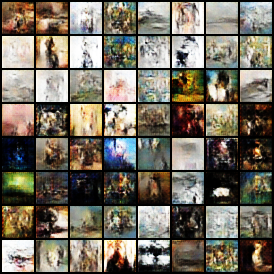

[ldim= 256] Epoch 50/100 | D_loss=0.6954 | G_loss=5.9476 | D(real)=0.8071 | D(fake)=0.0581
[ldim= 256] Epoch 51/100 | D_loss=0.8159 | G_loss=6.0317 | D(real)=0.8143 | D(fake)=0.0694
[ldim= 256] Epoch 52/100 | D_loss=0.7533 | G_loss=5.4380 | D(real)=0.8167 | D(fake)=0.0866
[ldim= 256] Epoch 53/100 | D_loss=0.7119 | G_loss=6.1363 | D(real)=0.8162 | D(fake)=0.0526
[ldim= 256] Epoch 54/100 | D_loss=0.6893 | G_loss=5.8786 | D(real)=0.8333 | D(fake)=0.0725
[ldim= 256] Epoch 55/100 | D_loss=0.8645 | G_loss=5.7202 | D(real)=0.8121 | D(fake)=0.0937
[ldim= 256] Epoch 56/100 | D_loss=0.9187 | G_loss=5.9115 | D(real)=0.8111 | D(fake)=0.0916
[ldim= 256] Epoch 57/100 | D_loss=0.9034 | G_loss=5.6102 | D(real)=0.8202 | D(fake)=0.0980
[ldim= 256] Epoch 58/100 | D_loss=0.6566 | G_loss=6.2872 | D(real)=0.8457 | D(fake)=0.0633
[ldim= 256] Epoch 59/100 | D_loss=0.7461 | G_loss=6.7207 | D(real)=0.8473 | D(fake)=0.0684
[ldim= 256] Epoch 60/100 | D_loss=0.7883 | G_loss=6.6412 | D(real)=0.8315 | D(fake)=0.0750

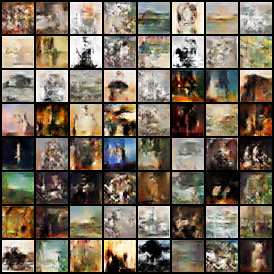

[ldim= 256] Epoch 75/100 | D_loss=0.7390 | G_loss=8.7542 | D(real)=0.8824 | D(fake)=0.0757
[ldim= 256] Epoch 76/100 | D_loss=0.5474 | G_loss=9.0394 | D(real)=0.8957 | D(fake)=0.0466
[ldim= 256] Epoch 77/100 | D_loss=0.5077 | G_loss=8.9682 | D(real)=0.9213 | D(fake)=0.0558
[ldim= 256] Epoch 78/100 | D_loss=0.7727 | G_loss=8.9181 | D(real)=0.8678 | D(fake)=0.0616
[ldim= 256] Epoch 79/100 | D_loss=0.5032 | G_loss=9.6488 | D(real)=0.9038 | D(fake)=0.0412
[ldim= 256] Epoch 80/100 | D_loss=0.8779 | G_loss=9.5347 | D(real)=0.8696 | D(fake)=0.0480
[ldim= 256] Epoch 81/100 | D_loss=0.5729 | G_loss=9.3246 | D(real)=0.9233 | D(fake)=0.0605
[ldim= 256] Epoch 82/100 | D_loss=0.8152 | G_loss=10.5027 | D(real)=0.8781 | D(fake)=0.0620
[ldim= 256] Epoch 83/100 | D_loss=0.5276 | G_loss=10.7013 | D(real)=0.9046 | D(fake)=0.0386
[ldim= 256] Epoch 84/100 | D_loss=0.7262 | G_loss=10.1192 | D(real)=0.8984 | D(fake)=0.0698
[ldim= 256] Epoch 85/100 | D_loss=0.6630 | G_loss=10.7660 | D(real)=0.9146 | D(fake)=0.

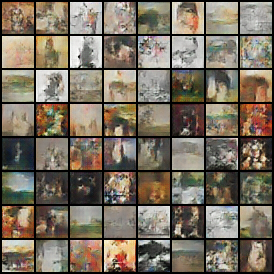

[ldim= 256] Epoch 100/100 | D_loss=0.3422 | G_loss=12.8558 | D(real)=0.9470 | D(fake)=0.0263
----------------------------------------------------------------------------------------------------
Finished dcgan_ldim256_ep100_seed42 | time=7.6 min
----------------------------------------------------------------------------------------------------

DCGAN TRAINING FINISHED
latent_dim=256 | final_g_loss=12.8558 | dir=c:\Users\User\source\repos\genai-project1\drive_outputs\runs\dcgan_ldim256_ep100_seed42

Summary CSV saved to: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\summary_dcgan.csv


In [16]:
import os
import csv
import json
import gc
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torchvision.utils import save_image, make_grid
from IPython.display import display as ipy_display, Image as IPyImage

# =========================
# Config
# =========================
latent_dim = 256

img_channels = 3
img_size = IMAGE_SIZE
hidden_dims = [32, 64, 128, 256]

learning_rate = 2e-4
beta1 = 0.5
beta2 = 0.999
num_epochs = 100

seed = 42
model_family = "dcgan"

# =========================
# Paths
# =========================
base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
base_runs_dir.mkdir(parents=True, exist_ok=True)

summary_csv_path = base_runs_dir / "summary_dcgan.csv"

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# Ensure GAN dataloaders exist
# =========================
if "train_loader_gan" not in globals() or "val_loader_gan" not in globals():
    print("train_loader_gan / val_loader_gan not found. Rebuilding them now...")

    transform_gan = T.Compose([
        T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
        T.CenterCrop(IMAGE_SIZE),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0,1] -> [-1,1]
    ])

    # assumes these already exist from your earlier notebook cells:
    # - train_hf
    # - train_ids_split
    # - val_ids_split
    # - HFDatasetTorch
    # - BATCH_SIZE
    # - EFFECTIVE_NUM_WORKERS

    train_ds_gan = HFDatasetTorch(train_hf, transform=transform_gan, indices=train_ids_split)
    val_ds_gan = HFDatasetTorch(train_hf, transform=transform_gan, indices=val_ids_split)

    train_loader_gan = DataLoader(
        train_ds_gan,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=EFFECTIVE_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader_gan = DataLoader(
        val_ds_gan,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=EFFECTIVE_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

print("=" * 100)
print(f"Device: {device}")
print(f"Train size: {len(train_loader_gan.dataset)} | Val size: {len(val_loader_gan.dataset)}")
print(f"Batch size: {train_loader_gan.batch_size}")
print(f"Latent dim: {latent_dim}")
print("=" * 100)


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def save_sample_grid(generator, noise, save_path, nrow=8):
    generator.eval()
    with torch.no_grad():
        fake = generator(noise).detach().cpu()
    fake = (fake + 1.0) / 2.0  # [-1,1] -> [0,1]
    fake = fake.clamp(0, 1)
    grid = make_grid(fake, nrow=nrow, padding=2)
    save_image(grid, save_path)
    generator.train()


def train_dcgan_for_latent_dim(latent_dim: int):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    run_name = f"dcgan_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
    run_dir = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    metrics_csv_path = run_dir / "metrics.csv"
    config_json_path = run_dir / "config.json"
    final_g_path = run_dir / "final_generator.pt"
    final_d_path = run_dir / "final_discriminator.pt"
    samples_dir = run_dir / "samples"
    samples_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir = run_dir / "checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    config = {
        "run_name": run_name,
        "model_family": model_family,
        "seed": seed,
        "latent_dim": latent_dim,
        "img_channels": img_channels,
        "img_size": img_size,
        "hidden_dims": hidden_dims,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "beta2": beta2,
        "num_epochs": num_epochs,
        "train_size": len(train_loader_gan.dataset),
        "val_size": len(val_loader_gan.dataset),
        "batch_size": train_loader_gan.batch_size,
    }
    save_json(config, config_json_path)

    G = Generator(
        latent_dim=latent_dim,
        img_channels=img_channels,
        img_size=img_size,
        hidden_dims=hidden_dims,
    ).to(device)

    D = Discriminator(
        img_channels=img_channels,
        hidden_dims=hidden_dims,
    ).to(device)

    G.apply(dcgan_weights_init)
    D.apply(dcgan_weights_init)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_G = optim.Adam(G.parameters(), lr=learning_rate, betas=(beta1, beta2))
    optimizer_D = optim.Adam(D.parameters(), lr=learning_rate, betas=(beta1, beta2))

    fixed_noise = torch.randn(64, latent_dim, device=device)

    fieldnames = [
        "epoch",
        "d_loss",
        "g_loss",
        "d_real_mean",
        "d_fake_mean",
    ]

    with open(metrics_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()



    print("\n" + "=" * 100)
    print(f"Starting run: {run_name}")
    print(f"Run dir: {run_dir}")
    print("=" * 100)

    start_time = time.time()

    for epoch in range(num_epochs):
        G.train()
        D.train()

        d_loss_sum = 0.0
        g_loss_sum = 0.0
        d_real_mean_sum = 0.0
        d_fake_mean_sum = 0.0
        num_batches = 0

        for batch in train_loader_gan:
            real_imgs = batch[0].to(device, non_blocking=True)
            batch_size = real_imgs.size(0)

            real_labels = torch.ones(batch_size, device=device)
            fake_labels = torch.zeros(batch_size, device=device)

            # -----------------
            # Train D
            # -----------------
            optimizer_D.zero_grad()

            real_logits = D(real_imgs)
            d_loss_real = criterion(real_logits, real_labels)

            z = torch.randn(batch_size, latent_dim, device=device)
            fake_imgs = G(z)

            fake_logits = D(fake_imgs.detach())
            d_loss_fake = criterion(fake_logits, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
            optimizer_D.step()

            # -----------------
            # Train G
            # -----------------
            optimizer_G.zero_grad()

            fake_logits_for_g = D(fake_imgs)  # reuse same fake_imgs from D step

            g_loss = criterion(fake_logits_for_g, real_labels)
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
            optimizer_G.step()

            d_loss_sum += d_loss.item()
            g_loss_sum += g_loss.item()
            d_real_mean_sum += torch.sigmoid(real_logits).mean().item()
            d_fake_mean_sum += torch.sigmoid(fake_logits_for_g).mean().item()
            num_batches += 1

        d_loss_epoch = d_loss_sum / num_batches
        g_loss_epoch = g_loss_sum / num_batches
        d_real_mean_epoch = d_real_mean_sum / num_batches
        d_fake_mean_epoch = d_fake_mean_sum / num_batches

        row = {
            "epoch": epoch + 1,
            "d_loss": d_loss_epoch,
            "g_loss": g_loss_epoch,
            "d_real_mean": d_real_mean_epoch,
            "d_fake_mean": d_fake_mean_epoch,
        }

        with open(metrics_csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writerow(row)

        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            periodic_path = ckpt_dir / f"checkpoint_epoch_{epoch+1:03d}.pt"
            torch.save(
                {
                    "epoch": epoch + 1,
                    "generator_state_dict": G.state_dict(),
                    "discriminator_state_dict": D.state_dict(),
                    "config": config,
                },
                periodic_path,
            )

        if (epoch + 1) % 25 == 0:
            sample_path = samples_dir / f"epoch_{epoch+1:03d}.png"
            save_sample_grid(G, fixed_noise, sample_path)
            print(f"GAN samples — epoch {epoch+1}")
            ipy_display(IPyImage(str(sample_path), width=500))

        print(
            f"[ldim={latent_dim:>4}] "
            f"Epoch {epoch+1:>2}/{num_epochs} | "
            f"D_loss={d_loss_epoch:.4f} | "
            f"G_loss={g_loss_epoch:.4f} | "
            f"D(real)={d_real_mean_epoch:.4f} | "
            f"D(fake)={d_fake_mean_epoch:.4f}"
        )

    total_time_sec = time.time() - start_time

    torch.save(
        {
            "epoch": num_epochs,
            "model_state_dict": G.state_dict(),
            "optimizer_state_dict": optimizer_G.state_dict(),
            "final_g_loss": g_loss_epoch,
            "config": config,
        },
        final_g_path,
    )

    torch.save(
        {
            "epoch": num_epochs,
            "model_state_dict": D.state_dict(),
            "optimizer_state_dict": optimizer_D.state_dict(),
            "config": config,
        },
        final_d_path,
    )

    summary_row = {
        "run_name": run_name,
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "final_g_loss": g_loss_epoch,
        "train_size": len(train_loader_gan.dataset),
        "val_size": len(val_loader_gan.dataset),
        "batch_size": train_loader_gan.batch_size,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "beta2": beta2,
        "run_dir": str(run_dir),
        "final_g_path": str(final_g_path),
        "final_d_path": str(final_d_path),
        "time_sec": total_time_sec,
        "status": "ok",
    }

    print("-" * 100)
    print(
        f"Finished {run_name} | "
        f"time={total_time_sec/60:.1f} min"
    )
    print("-" * 100)

    return summary_row


# =========================
# Run all latent dims
# =========================
summary_fieldnames = [
    "run_name",
    "latent_dim",
    "num_epochs",
    "final_g_loss",
    "train_size",
    "val_size",
    "batch_size",
    "learning_rate",
    "beta1",
    "beta2",
    "run_dir",
    "final_g_path",
    "final_d_path",
    "time_sec",
    "status",
]

all_results = []

with open(summary_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writeheader()

try:
    result = train_dcgan_for_latent_dim(latent_dim)

except RuntimeError as e:
    result = {
        "run_name": f"dcgan_ldim{latent_dim}_ep{num_epochs}_seed{seed}",
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "final_g_loss": None,
        "train_size": len(train_loader_gan.dataset),
        "val_size": len(val_loader_gan.dataset),
        "batch_size": train_loader_gan.batch_size,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "beta2": beta2,
        "run_dir": "",
        "final_g_path": "",
        "final_d_path": "",
        "time_sec": None,
        "status": f"runtime_error: {str(e)}",
    }
    print("\n" + "!" * 100)
    print(f"Run failed for latent_dim={latent_dim}")
    print(str(e))
    print("!" * 100)

with open(summary_csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writerow(result)

all_results.append(result)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =========================
# Final ranking print
# =========================
ok_results = [r for r in all_results if r["status"] == "ok" and r["final_g_loss"] is not None]
ok_results = sorted(ok_results, key=lambda x: (x["final_g_loss"] or float('inf')))

print("\n" + "=" * 100)
print("DCGAN TRAINING FINISHED")
print("=" * 100)

if all_results and all_results[0]["status"] == "ok":
    r = all_results[0]
    print(f"latent_dim={r['latent_dim']} | final_g_loss={r['final_g_loss']:.4f} | dir={r['run_dir']}")
else:
    print("Training failed.")

print(f"\nSummary CSV saved to: {summary_csv_path}")

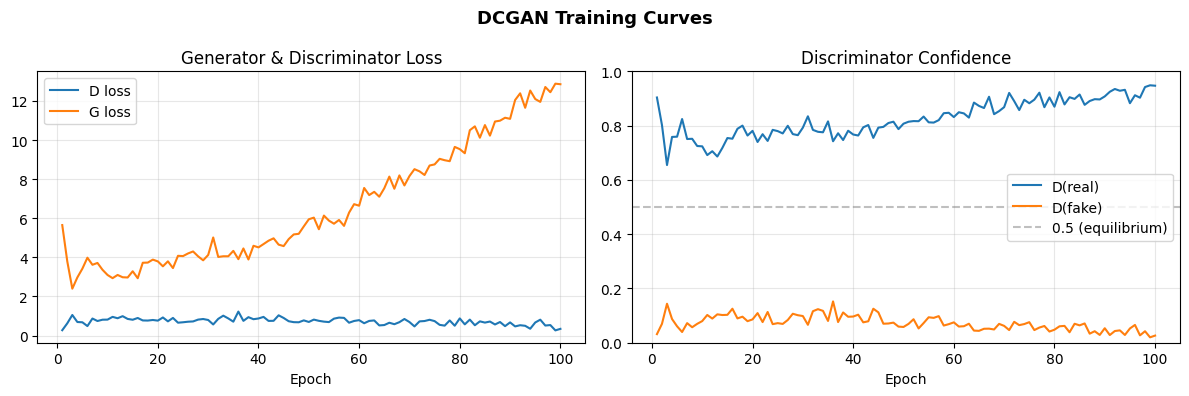

In [19]:
# GAN — Loss Curves
import csv
import matplotlib.pyplot as plt
from pathlib import Path

_runs = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
_metrics = _runs / "dcgan_ldim256_ep100_seed42" / "metrics.csv"

if _metrics.exists():
    ep, d_loss, g_loss, d_real, d_fake = [], [], [], [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            d_loss.append(float(row["d_loss"]));     g_loss.append(float(row["g_loss"]))
            d_real.append(float(row["d_real_mean"])); d_fake.append(float(row["d_fake_mean"]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ep, d_loss, label="D loss")
    axes[0].plot(ep, g_loss, label="G loss")
    axes[0].set_title("Generator & Discriminator Loss")
    axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, d_real, label="D(real)")
    axes[1].plot(ep, d_fake, label="D(fake)")
    axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="0.5 (equilibrium)")
    axes[1].set_title("Discriminator Confidence")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylim(0, 1)
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    fig.suptitle("DCGAN Training Curves", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


## Sample from DCGAN

Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\dcgan_ldim256_ep100_seed42
Loaded epoch: 100 | Final G loss: 12.8558


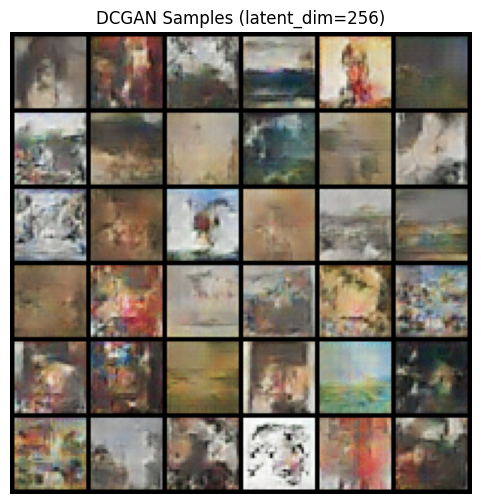

In [20]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from pathlib import Path

base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 256
num_epochs = 100
seed = 42

def show_image_grid(images, n_images=36, nrow=6, title="Image Grid"):
    images = images[:n_images].detach().cpu()
    images = (images + 1.0) / 2.0  # GAN outputs [-1, 1]
    images = images.clamp(0, 1)
    grid = make_grid(images, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(np_img)
    plt.axis("off")
    plt.title(title)
    plt.show()


torch.manual_seed(seed)

run_name = f"dcgan_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
run_dir = base_runs_dir / run_name
ckpt_path = run_dir / "final_generator.pt"

print(f"Run dir: {run_dir}")

if not ckpt_path.exists():
    print(f"Checkpoint not found: {ckpt_path}")
else:
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg = checkpoint["config"]

    G = Generator(
        latent_dim=cfg["latent_dim"],
        img_channels=cfg["img_channels"],
        img_size=cfg["img_size"],
        hidden_dims=cfg["hidden_dims"],
    ).to(device)

    G.load_state_dict(checkpoint["model_state_dict"])
    G.eval()

    print(f"Loaded epoch: {checkpoint['epoch']} | Final G loss: {checkpoint['final_g_loss']:.4f}")

    with torch.no_grad():
        z = torch.randn(36, cfg["latent_dim"], device=device)
        samples = G(z)

    show_image_grid(samples, n_images=36, nrow=6, title=f"DCGAN Samples (latent_dim={latent_dim})")


---
# Diffusion Model

---




In [21]:
"""Diffusion Model for ArtBench-10."""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def sinusoidal_embeddings(n_steps: int, dim: int) -> torch.Tensor:
    """Fixed sinusoidal embeddings table (interleaved sin/cos), shape (n_steps, dim)."""
    emb = torch.zeros(n_steps, dim)
    position = torch.arange(0, n_steps).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2) * (-math.log(10000.0) / dim))
    emb[:, 0::2] = torch.sin(position * div_term)
    emb[:, 1::2] = torch.cos(position * div_term)
    return emb


def _get_groups(channels: int, num_groups: int = 8) -> int:
    """Find largest divisor of channels that is <= num_groups."""
    g = max(1, min(num_groups, channels))
    while channels % g != 0:
        g -= 1
    return g


class ResBlock(nn.Module):
    """Residual block with timestep conditioning."""

    def __init__(self, in_channels: int, out_channels: int, time_emb_dim: int, num_groups: int = 8, dropout: float = 0.0):
        super().__init__()

        self.norm1 = nn.GroupNorm(_get_groups(in_channels, num_groups), in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.time_emb_proj = nn.Linear(time_emb_dim, out_channels)

        self.norm2 = nn.GroupNorm(_get_groups(out_channels, num_groups), out_channels)
        self.act2 = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_emb_proj(time_emb)[:, :, None, None]
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))
        return h + self.skip(x)


class DownBlock(nn.Module):
    """Two ResBlocks (maintain channels) + strided conv that changes channels."""

    def __init__(self, channels: int, next_channels: int, time_emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.res1 = ResBlock(channels, channels, time_emb_dim, dropout=dropout)
        self.res2 = ResBlock(channels, channels, time_emb_dim, dropout=dropout)
        self.down = nn.Conv2d(channels, next_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor):
        x = self.res1(x, time_emb)
        x = self.res2(x, time_emb)
        skip = x          # saved before downsampling, at original channels
        x = self.down(x)  # spatial downsample + channel change
        return x, skip


class UpBlock(nn.Module):
    """Transposed conv + concat skip + two ResBlocks."""

    def __init__(self, in_channels: int, out_channels: int, skip_channels: int, time_emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.res1 = ResBlock(out_channels + skip_channels, out_channels, time_emb_dim, dropout=dropout)
        self.res2 = ResBlock(out_channels, out_channels, time_emb_dim, dropout=dropout)

    def forward(self, x: torch.Tensor, skip: torch.Tensor, time_emb: torch.Tensor):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.res1(x, time_emb)
        x = self.res2(x, time_emb)
        return x


class UNet(nn.Module):
    """UNet for diffusion denoising. Structurally identical to UNet32 from Antonio's notebook."""

    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        dropout: float = 0.0,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [64, 128, 256]

        self.time_emb_dim = time_emb_dim
        self.hidden_dims = hidden_dims

        # Timestep embedding: fixed sinusoidal lookup, then MLP
        embed_dim = hidden_dims[0]
        self.time_embed = nn.Embedding(num_steps, embed_dim)
        self.time_embed.weight.data = sinusoidal_embeddings(num_steps, embed_dim)
        self.time_embed.weight.requires_grad = False

        self.time_mlp = nn.Sequential(
            nn.Linear(embed_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.initial_conv = nn.Conv2d(img_channels, hidden_dims[0], kernel_size=3, padding=1)

        # Down path: len(hidden_dims) levels, 32 -> 16 -> 8 -> 4
        # Channels at each level: hidden_dims[i]
        # Downsampling conv changes to hidden_dims[i+1] (last level stays same)
        self.downs = nn.ModuleList()
        for i, ch in enumerate(hidden_dims):
            next_ch = hidden_dims[i + 1] if i < len(hidden_dims) - 1 else hidden_dims[-1]
            self.downs.append(DownBlock(ch, next_ch, time_emb_dim, dropout=dropout))

        # Bottleneck at 4x4
        self.mid1 = ResBlock(hidden_dims[-1], hidden_dims[-1], time_emb_dim, dropout=dropout)
        self.mid2 = ResBlock(hidden_dims[-1], hidden_dims[-1], time_emb_dim, dropout=dropout)

        # Up path: len(hidden_dims) levels, 4 -> 8 -> 16 -> 32
        # skip channels = hidden_dims reversed (d3=256, d2=128, d1=64)
        # upsample channel pattern: 256->256->128->64
        self.ups = nn.ModuleList()
        rev = list(reversed(hidden_dims))   # [256, 128, 64]
        in_ch = hidden_dims[-1]
        for i, skip_ch in enumerate(rev):
            out_ch = rev[i]
            self.ups.append(UpBlock(in_ch, out_ch, skip_ch, time_emb_dim, dropout=dropout))
            in_ch = out_ch

        # Final output: GroupNorm + SiLU + Conv
        out_ch = hidden_dims[0]
        self.out = nn.Sequential(
            nn.GroupNorm(_get_groups(out_ch), out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, img_channels, kernel_size=3, padding=1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Noisy image (B, C, H, W)
            t: Timestep indices (B,) as long integers

        Returns:
            predicted_noise: (B, C, H, W)
        """
        t_emb = self.time_mlp(self.time_embed(t.long()))

        x = self.initial_conv(x)

        skips = []
        for down in self.downs:
            x, skip = down(x, t_emb)
            skips.append(skip)

        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        for up in self.ups:
            x = up(x, skips.pop(), t_emb)

        return self.out(x)


class DiffusionScheduler(nn.Module):
    """Linear diffusion schedule with registered buffers."""

    def __init__(self, num_steps: int = 1000, beta_start: float = 1e-4, beta_end: float = 2e-2):
        super().__init__()

        self.num_steps = num_steps

        betas = torch.linspace(beta_start, beta_end, num_steps)
        alphas = 1.0 - betas
        alpha_cumprod = torch.cumprod(alphas, dim=0)
        alpha_cumprod_prev = torch.cat([torch.ones(1), alpha_cumprod[:-1]], dim=0)

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alpha_cumprod", alpha_cumprod)
        self.register_buffer("alpha_cumprod_prev", alpha_cumprod_prev)

        self.register_buffer("sqrt_alpha_cumprod", torch.sqrt(alpha_cumprod))
        self.register_buffer("sqrt_one_minus_alpha_cumprod", torch.sqrt(1.0 - alpha_cumprod))
        self.register_buffer("sqrt_recip_alphas", torch.sqrt(1.0 / alphas))

        posterior_variance = betas * (1.0 - alpha_cumprod_prev) / (1.0 - alpha_cumprod)
        self.register_buffer("posterior_variance", torch.clamp(posterior_variance, min=1e-20))

    def q_sample(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
        """Forward diffusion: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * noise"""
        return (
            self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1) * x_0
            + self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1) * noise
        )


class Diffusion(nn.Module):
    """Diffusion model for image generation."""

    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        beta_end: float = 0.02,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.num_steps = num_steps

        self.unet = UNet(
            img_channels=img_channels,
            hidden_dims=hidden_dims,
            time_emb_dim=time_emb_dim,
            num_steps=num_steps,
            dropout=dropout,
        )

        self.scheduler = DiffusionScheduler(num_steps=num_steps, beta_end=beta_end)

    def forward(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        if noise is None:
            noise = torch.randn_like(x_0)
        x_t = self.scheduler.q_sample(x_0, t, noise)
        return self.unet(x_t, t)

    @torch.no_grad()
    def sample(
        self,
        num_samples: int,
        shape: tuple = (3, 32, 32),
        device: torch.device | str | None = None,
        num_inference_steps: int | None = None,
    ) -> torch.Tensor:
        """Generate samples via reverse diffusion. Returns images in [0, 1]."""
        self.eval()

        if device is None:
            device = next(self.parameters()).device
        if isinstance(device, str):
            device = torch.device(device)

        if num_inference_steps is None:
            timesteps = torch.arange(self.num_steps - 1, -1, -1, device=device)
        else:
            timesteps = torch.linspace(self.num_steps - 1, 0, num_inference_steps, device=device).long()

        x = torch.randn(num_samples, *shape, device=device)

        for t_scalar in timesteps:
            t_idx = int(t_scalar.item())
            t = torch.full((num_samples,), t_idx, device=device, dtype=torch.long)

            beta_t = self.scheduler.betas[t_idx].view(1, 1, 1, 1)
            sqrt_one_minus_abar = self.scheduler.sqrt_one_minus_alpha_cumprod[t_idx].view(1, 1, 1, 1)
            sqrt_recip_alpha = self.scheduler.sqrt_recip_alphas[t_idx].view(1, 1, 1, 1)

            pred_noise = self.unet(x, t)
            model_mean = sqrt_recip_alpha * (x - beta_t * pred_noise / (sqrt_one_minus_abar + 1e-8))

            if t_idx > 0:
                x = model_mean + torch.sqrt(beta_t) * torch.randn_like(x)
            else:
                x = model_mean

        return torch.clamp(x, 0, 1)


## Train Diffusion Model

In [22]:
import os
import gc
import json
import time
import csv
from pathlib import Path

import torch.nn.functional as F
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# =========================
# Config
# =========================
SEED = 42
seed = SEED
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

base_runs_dir = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
base_runs_dir.mkdir(parents=True, exist_ok=True)

# Fixed diffusion architecture (no latent_dim sweep)
diffusion_hidden_dims = [64, 128, 256]
diffusion_time_emb_dim = 256
num_epochs = 100
learning_rate = 2e-4
weight_decay = 0.0

img_channels = 3
img_size = IMAGE_SIZE
num_diffusion_steps = 1000

summary_csv_path = base_runs_dir / "diffusion_summary.csv"


def get_diffusion_arch_from_latent_dim(latent_dim: int) -> tuple[list[int], int]:
    latent_dim = int(latent_dim)
    if latent_dim <= 64:
        hidden_dims = [32, 64, 128]
    elif latent_dim <= 256:
        hidden_dims = [64, 128, 256]
    else:
        hidden_dims = [96, 192, 384]

    time_emb_dim = max(64, min(512, latent_dim))
    return hidden_dims, time_emb_dim


def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def train_diffusion_for_latent_dim(latent_dim):
    """Train diffusion model and return summary."""

    run_name = f"diffusion_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
    run_dir = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_dir = run_dir / "checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    samples_dir = run_dir / "samples"
    samples_dir.mkdir(parents=True, exist_ok=True)

    best_ckpt_path = ckpt_dir / "best_model.pt"
    final_ckpt_path = ckpt_dir / "final_model.pt"
    config_json_path = run_dir / "config.json"
    metrics_csv_path = run_dir / "metrics.csv"

    hidden_dims, time_emb_dim = diffusion_hidden_dims, diffusion_time_emb_dim

    # Config
    config = {
        "run_name": run_name,
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "img_channels": img_channels,
        "img_size": img_size,
        "hidden_dims": hidden_dims,
        "time_emb_dim": time_emb_dim,
        "num_diffusion_steps": num_diffusion_steps,
        "train_size": len(train_loader_from_csv.dataset),
        "val_size": len(val_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
    }
    save_json(config, config_json_path)

    # Model
    model = Diffusion(
        img_channels=img_channels,
        hidden_dims=hidden_dims,
        time_emb_dim=time_emb_dim,
        num_steps=num_diffusion_steps,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    fieldnames = ["epoch", "train_loss", "val_loss"]
    with open(metrics_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

    best_val_loss = float("inf")
    best_epoch = -1

    print("\n" + "=" * 100)
    print(f"Starting run: {run_name}")
    print(f"Run dir: {run_dir}")
    print(f"hidden_dims={hidden_dims} | time_emb_dim={time_emb_dim}")
    print("=" * 100)

    start_time = time.time()

    for epoch in range(num_epochs):
        # ---- TRAIN ----
        model.train()
        train_loss_sum = 0.0
        train_num_batches = 0

        for batch in train_loader_from_csv:
            x = batch[0].to(device, non_blocking=True)

            batch_size = x.shape[0]

            # Sample random timesteps
            t = torch.randint(0, num_diffusion_steps, (batch_size,), device=device)

            # Sample random noise
            noise = torch.randn_like(x)

            optimizer.zero_grad()

            # Forward pass: predict noise
            predicted_noise = model(x, t, noise)

            # MSE loss
            loss = F.mse_loss(predicted_noise, noise)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_num_batches += 1

        train_loss = train_loss_sum / max(train_num_batches, 1)

        # ---- VALIDATION ----
        model.eval()
        val_loss_sum = 0.0
        val_num_batches = 0

        with torch.no_grad():
            for batch in val_loader_from_csv:
                x = batch[0].to(device, non_blocking=True)
                batch_size = x.shape[0]

                t = torch.randint(0, num_diffusion_steps, (batch_size,), device=device)
                noise = torch.randn_like(x)

                predicted_noise = model(x, t, noise)
                loss = F.mse_loss(predicted_noise, noise)

                val_loss_sum += loss.item()
                val_num_batches += 1

        val_loss = val_loss_sum / max(val_num_batches, 1)

        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
        }

        with open(metrics_csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writerow(row)

        # ---- Save best ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1

            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_loss": best_val_loss,
                    "config": config,
                },
                best_ckpt_path,
            )

        print(
            f"[ldim={latent_dim:>4}] "
            f"Epoch {epoch+1:>2}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f}"
        )

    total_time_sec = time.time() - start_time

    # ---- Save final checkpoint ----
    torch.save(
        {
            "epoch": num_epochs,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
            "config": config,
        },
        final_ckpt_path,
    )

    summary_row = {
        "run_name": run_name,
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "train_size": len(train_loader_from_csv.dataset),
        "val_size": len(val_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "run_dir": str(run_dir),
        "best_ckpt_path": str(best_ckpt_path),
        "final_ckpt_path": str(final_ckpt_path),
        "time_sec": total_time_sec,
        "status": "ok",
    }

    print("-" * 100)
    print(
        f"Finished {run_name} | "
        f"best_val_loss={best_val_loss:.4f} | "
        f"best_epoch={best_epoch} | "
        f"time={total_time_sec/60:.1f} min"
    )
    print("-" * 100)

    return summary_row


# =========================
# Run all latent dims
# =========================
summary_fieldnames = [
    "run_name",
    "latent_dim",
    "num_epochs",
    "best_epoch",
    "best_val_loss",
    "train_size",
    "val_size",
    "batch_size",
    "learning_rate",
    "weight_decay",
    "run_dir",
    "best_ckpt_path",
    "final_ckpt_path",
    "time_sec",
    "status",
]

all_results = []

with open(summary_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writeheader()

# Single fixed architecture training
latent_dim = 256  # used for run naming only
try:
    result = train_diffusion_for_latent_dim(latent_dim)

except RuntimeError as e:
        result = {
            "run_name": f"diffusion_ldim{latent_dim}_ep{num_epochs}_seed{seed}",
            "latent_dim": latent_dim,
            "num_epochs": num_epochs,
            "best_epoch": None,
            "best_val_loss": None,
            "train_size": len(train_loader_from_csv.dataset),
            "val_size": len(val_loader_from_csv.dataset),
            "batch_size": train_loader_from_csv.batch_size,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "run_dir": "",
            "best_ckpt_path": "",
            "final_ckpt_path": "",
            "time_sec": None,
            "status": f"runtime_error: {str(e)}",
        }
        print("\n" + "!" * 100)
        print(f"Run failed for latent_dim={latent_dim}")
        print(str(e))
        print("!" * 100)

with open(summary_csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writerow(result)

all_results.append(result)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =========================
# Final ranking print
# =========================
ok_results = [r for r in all_results if r["status"] == "ok" and r["best_val_loss"] is not None]
ok_results = sorted(ok_results, key=lambda x: x["best_val_loss"])

print("\n" + "=" * 100)
print("DIFFUSION TRAINING FINISHED")
print("=" * 100)

if all_results and all_results[0]["status"] == "ok":
    r = all_results[0]
    print(f"latent_dim={r['latent_dim']} | best_val_loss={r['best_val_loss']:.4f} | best_epoch={r['best_epoch']} | dir={r['run_dir']}")
else:
    print("Training failed.")

print(f"\nSummary CSV saved to: {summary_csv_path}")

Device: cuda

Starting run: diffusion_ldim256_ep100_seed42
Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\diffusion_ldim256_ep100_seed42
hidden_dims=[64, 128, 256] | time_emb_dim=256
[ldim= 256] Epoch  1/100 | train_loss=0.1646 | val_loss=0.0546
[ldim= 256] Epoch  2/100 | train_loss=0.0548 | val_loss=0.0351
[ldim= 256] Epoch  3/100 | train_loss=0.0435 | val_loss=0.0331
[ldim= 256] Epoch  4/100 | train_loss=0.0387 | val_loss=0.0279
[ldim= 256] Epoch  5/100 | train_loss=0.0346 | val_loss=0.0296
[ldim= 256] Epoch  6/100 | train_loss=0.0327 | val_loss=0.0268
[ldim= 256] Epoch  7/100 | train_loss=0.0331 | val_loss=0.0302
[ldim= 256] Epoch  8/100 | train_loss=0.0299 | val_loss=0.0271
[ldim= 256] Epoch  9/100 | train_loss=0.0303 | val_loss=0.0283
[ldim= 256] Epoch 10/100 | train_loss=0.0267 | val_loss=0.0267
[ldim= 256] Epoch 11/100 | train_loss=0.0279 | val_loss=0.0255
[ldim= 256] Epoch 12/100 | train_loss=0.0275 | val_loss=0.0258
[ldim= 256] Epoch 13/100 | train_loss=

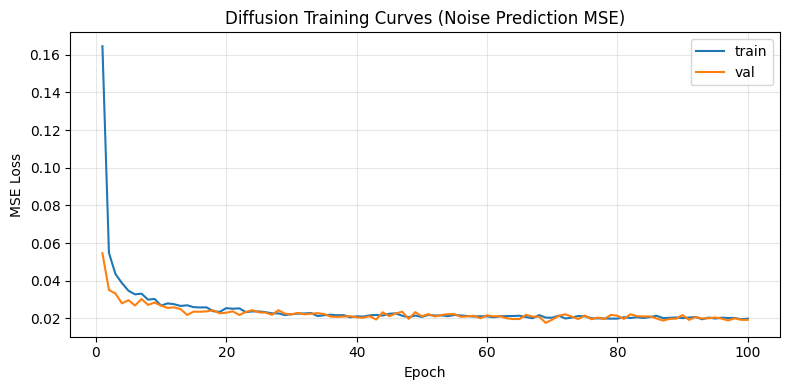

In [23]:
# Diffusion — Loss Curves
import csv
import matplotlib.pyplot as plt
from pathlib import Path

_runs = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
_metrics = _runs / "diffusion_ldim256_ep100_seed42" / "metrics.csv"

if _metrics.exists():
    ep, tr_loss, vl_loss = [], [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            tr_loss.append(float(row["train_loss"]))
            vl_loss.append(float(row["val_loss"]))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ep, tr_loss, label="train")
    ax.plot(ep, vl_loss, label="val")
    ax.set_title("Diffusion Training Curves (Noise Prediction MSE)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


## Sample from Diffusion

Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\diffusion_ldim256_ep100_seed42
Loaded epoch: 69 | Best val loss: 0.0175
hidden_dims: [64, 128, 256] | time_emb_dim: 256


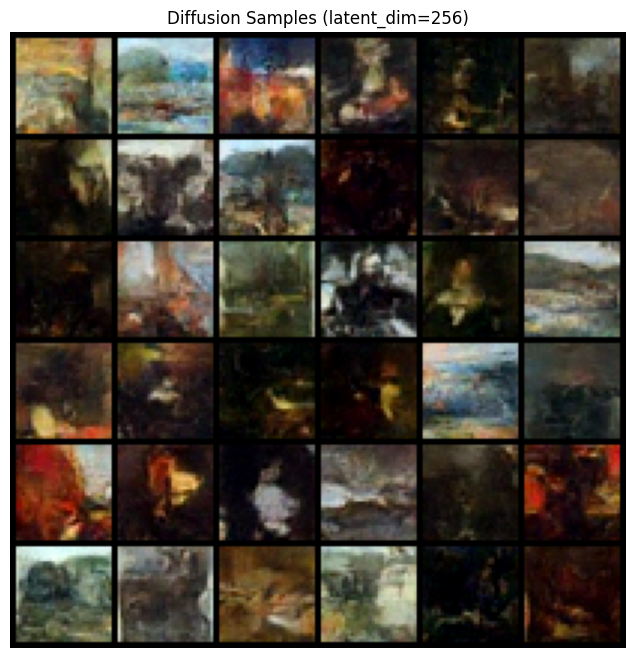

In [24]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from pathlib import Path

base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 256
num_epochs = 100
seed = 42

def show_image_grid(images, n_images=36, nrow=6, title="Image Grid"):
    images = images[:n_images].detach().cpu()
    images = images.clamp(0, 1)  # Diffusion outputs [0, 1]
    grid = make_grid(images, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).numpy()
    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis("off")
    plt.title(title)
    plt.show()


torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

run_name = f"diffusion_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
run_dir = base_runs_dir / run_name
best_ckpt_path = run_dir / "checkpoints" / "best_model.pt"

print(f"Run dir: {run_dir}")

if not best_ckpt_path.exists():
    print(f"Checkpoint not found: {best_ckpt_path}")
else:
    checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
    cfg = checkpoint.get("config", {})

    model = Diffusion(
        img_channels=cfg.get("img_channels", 3),
        hidden_dims=cfg.get("hidden_dims", [64, 128, 256]),
        time_emb_dim=cfg.get("time_emb_dim", 256),
        num_steps=cfg.get("num_diffusion_steps", 1000),
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print(f"Loaded epoch: {checkpoint['epoch']} | Best val loss: {checkpoint['best_val_loss']:.4f}")
    print(f"hidden_dims: {cfg.get('hidden_dims')} | time_emb_dim: {cfg.get('time_emb_dim')}")

    with torch.no_grad():
        samples = model.sample(
            num_samples=36,
            shape=(3, IMAGE_SIZE, IMAGE_SIZE),
            device=device,
            num_inference_steps=None,  # full 1000 steps — skip-step DDPM gives noise
        )

    show_image_grid(samples, n_images=36, nrow=6, title=f"Diffusion Samples (latent_dim={latent_dim})")


# Evaluation: FID and KID computation.

In [25]:
!pip install torchmetrics[image]

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.6 MB ? eta -:--:--
    --------------------------------------- 0.5/36.6 MB 645.7 kB/s eta 0:00:56
    --------------------------------------- 0.5/36.6 MB 645.7 kB/s eta 0:00:56
    --------------------------------------- 0.5/36.6 MB 645.7 kB/s eta 0:00:56
    --------------------------------------- 0.5/36.6 MB 645.7 kB/s eta 0:00:56
    --------------------------------------- 0.5/36.6 MB 645.7 kB/s eta 0:00:56
    --------------------------------------- 0.8/36.6 MB 377.2 kB/s eta 0:01:35
   - -------------------------------

In [26]:
"""
Evaluation: FID and KID computation.
Requires: pip install torchmetrics[image]
"""

import numpy as np
from torch.utils.data import DataLoader, Subset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance


def generate_samples(model, model_type, num_samples, latent_dim, img_channels, img_size, device, num_inference_steps=None):
    """Generate samples. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    model.eval()
    model.to(device)
    results = []
    batch_size = 64
    with torch.no_grad():
        generated = 0
        while generated < num_samples:
            n = min(batch_size, num_samples - generated)
            if model_type == "vae":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model.decode(z)
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "gan":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model(z)
                imgs = (imgs + 1.0) / 2.0
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "diffusion":
                imgs = model.sample(
                    num_samples=n,
                    shape=(img_channels, img_size, img_size),
                    device=device,
                    num_inference_steps=num_inference_steps,
                )
                imgs = torch.clamp(imgs, 0.0, 1.0)
            else:
                raise ValueError(f"Unknown model_type: {model_type}")
            results.append((imgs * 255).byte().cpu())
            generated += n
    return torch.cat(results, dim=0)[:num_samples]


def get_real_samples(dataset, num_samples, seed):
    """Sample real images from dataset. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    rng = torch.Generator()
    rng.manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=rng)[:num_samples].tolist()
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=128, shuffle=False, num_workers=0)
    imgs_list = []
    for batch in loader:
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        imgs_list.append((imgs * 255).byte())
    return torch.cat(imgs_list, dim=0)[:num_samples]


def compute_fid_kid_single(fake_imgs_uint8, real_imgs_uint8, kid_subset_size, device):
    """Compute FID and KID. Returns (fid, kid_mean, kid_std)."""
    bs = 128
    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        fid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        fid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    fid_val = fid_metric.compute().item()
    del fid_metric

    kid_metric = KernelInceptionDistance(subset_size=kid_subset_size, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        kid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        kid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    kid_mean, kid_std = kid_metric.compute()
    del kid_metric

    return fid_val, kid_mean.item(), kid_std.item()


def evaluate_model(
    model,
    real_dataset,
    model_type,
    latent_dim=128,
    img_channels=3,
    img_size=32,
    num_generated=5000,
    num_real=5000,
    kid_subset_size=100,
    n_repetitions=10,
    base_seed=0,
    device="cuda",
    num_inference_steps=None,
):
    """Full evaluation: n_repetitions with different seeds. Reports mean±std of FID and KID."""
    fid_list, kid_mean_list = [], []
    for rep in range(n_repetitions):
        seed = base_seed + rep * 137
        torch.manual_seed(seed)
        np.random.seed(seed)
        fake_imgs = generate_samples(model, model_type, num_generated, latent_dim, img_channels, img_size, device, num_inference_steps)
        real_imgs = get_real_samples(real_dataset, num_real, seed)
        fid, kid_m, kid_s = compute_fid_kid_single(fake_imgs, real_imgs, kid_subset_size, device)
        fid_list.append(fid)
        kid_mean_list.append(kid_m)
        print(f"  [{model_type}] Rep {rep+1}/{n_repetitions} seed={seed} | FID={fid:.2f} | KID={kid_m*1000:.4f}±{kid_s*1000:.4f} (×10⁻³)")

    results = {
        "model_type": model_type,
        "fid_mean": float(np.mean(fid_list)),
        "fid_std": float(np.std(fid_list)),
        "kid_mean": float(np.mean(kid_mean_list)),
        "kid_std": float(np.std(kid_mean_list)),
        "n_repetitions": n_repetitions,
        "num_generated": num_generated,
        "num_real": num_real,
    }
    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} | FID: {results['fid_mean']:.2f} ± {results['fid_std']:.2f} | KID: {results['kid_mean']*1000:.4f} ± {results['kid_std']*1000:.4f} (×10⁻³)")
    print(f"{'='*60}\n")
    return results


print("Evaluation functions loaded.")


Evaluation functions loaded.


In [27]:
"""
Run FID/KID evaluation for all trained models.
Auto-discovers the best checkpoint for each model from the summary CSVs.
Requires: pip install torchmetrics[image]
"""
import csv as _csv
import json as _json
from pathlib import Path

EVAL_NUM_GENERATED = 5000
EVAL_NUM_REAL      = 5000
EVAL_KID_SUBSET    = 100
EVAL_N_REPS        = 10
EVAL_BASE_SEED     = 0
EVAL_DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_runs = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
all_eval_results   = {}


def _best_row(csv_path, key_col, lower_is_better=True):
    """Return the row dict with the best value in key_col from status==ok rows."""
    if not Path(csv_path).exists():
        return None
    rows = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in _csv.DictReader(f):
            if row.get("status") == "ok":
                try:
                    rows.append((float(row[key_col]), row))
                except (ValueError, KeyError):
                    pass
    if not rows:
        return None
    rows.sort(key=lambda x: x[0], reverse=not lower_is_better)
    return rows[0][1]


# ═══════════════════════════════════════════════════════════════
# VAE  — best run by lowest best_val_loss
# ═══════════════════════════════════════════════════════════════
_vae_row       = _best_row(_runs / "summary_vae.csv", "best_val_loss")
_vae_ckpt_path = Path(_vae_row["best_ckpt_path"]) if _vae_row else None

if _vae_ckpt_path and _vae_ckpt_path.exists():
    print(f"[VAE] Loading from: {_vae_ckpt_path}")
    _ckpt  = torch.load(_vae_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = VAE(
        img_channels=_cfg["img_channels"],
        image_size=_cfg["image_size"],
        latent_dim=_cfg["latent_dim"],
        hidden_dims=_cfg["hidden_dims"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()
    all_eval_results["vae"] = evaluate_model(
        model=_model, real_dataset=val_ds_from_csv, model_type="vae",
        latent_dim=_cfg["latent_dim"],
        img_channels=_cfg["img_channels"], img_size=_cfg["image_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()
else:
    print(f"[VAE] Checkpoint not found — skipping. (path={_vae_ckpt_path})")


# ═══════════════════════════════════════════════════════════════
# GAN  — best run by lowest final_g_loss
# ═══════════════════════════════════════════════════════════════
_gan_row       = _best_row(_runs / "summary_dcgan.csv", "final_g_loss")
_gan_ckpt_path = Path(_gan_row["final_g_path"]) if _gan_row else None

if _gan_ckpt_path and _gan_ckpt_path.exists():
    print(f"[GAN] Loading from: {_gan_ckpt_path}")
    _ckpt  = torch.load(_gan_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = Generator(
        latent_dim=_cfg["latent_dim"],
        img_channels=_cfg["img_channels"],
        img_size=_cfg["img_size"],
        hidden_dims=_cfg["hidden_dims"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()
    all_eval_results["gan"] = evaluate_model(
        model=_model, real_dataset=val_ds_from_csv, model_type="gan",
        latent_dim=_cfg["latent_dim"],
        img_channels=_cfg["img_channels"], img_size=_cfg["img_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()
else:
    print(f"[GAN] Checkpoint not found — skipping. (path={_gan_ckpt_path})")


# ═══════════════════════════════════════════════════════════════
# Diffusion  — single fixed run (ldim256_ep100_seed42)
# ═══════════════════════════════════════════════════════════════
_diff_ckpt_path = _runs / "diffusion_ldim256_ep100_seed42" / "checkpoints" / "best_model.pt"
if not _diff_ckpt_path.exists():
    _diff_ckpt_path = _runs / "diffusion_ldim256_ep100_seed42" / "checkpoints" / "final_model.pt"

if _diff_ckpt_path.exists():
    print(f"[Diffusion] Loading from: {_diff_ckpt_path}")
    _ckpt  = torch.load(_diff_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = Diffusion(
        img_channels=_cfg["img_channels"],
        hidden_dims=_cfg["hidden_dims"],
        time_emb_dim=_cfg["time_emb_dim"],
        num_steps=_cfg["num_diffusion_steps"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()
    all_eval_results["diffusion"] = evaluate_model(
        model=_model, real_dataset=val_ds_from_csv, model_type="diffusion",
        latent_dim=0,  # unused for diffusion
        img_channels=_cfg["img_channels"], img_size=_cfg["img_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
        num_inference_steps=None,  # full 1000 steps for final evaluation
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()
else:
    print(f"[Diffusion] Checkpoint not found at {_diff_ckpt_path} — skipping.")


# ═══════════════════════════════════════════════════════════════
# Save results
# ═══════════════════════════════════════════════════════════════
if all_eval_results:
    _out = _runs / "evaluation_results.json"
    with open(_out, "w") as f:
        _json.dump(all_eval_results, f, indent=2)
    print(f"\nSaved to {_out}")
    print(f"\n{'Model':<12} {'FID':>10} {'FID±':>8} {'KID×10³':>12} {'KID±×10³':>12}")
    print("-" * 56)
    for name, res in all_eval_results.items():
        print(
            f"{name.upper():<12} "
            f"{res['fid_mean']:>10.2f} "
            f"{res['fid_std']:>8.2f} "
            f"{res['kid_mean']*1000:>12.4f} "
            f"{res['kid_std']*1000:>12.4f}"
        )
else:
    print("No models evaluated. Run the training cells first.")


[VAE] Loading from: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\vae_ldim256_ep100_seed42\best_model.pt


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\User/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [02:22<00:00, 671kB/s] 
c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  [vae] Rep 1/10 seed=0 | FID=257.48 | KID=256.1359±11.0777 (×10⁻³)
  [vae] Rep 2/10 seed=137 | FID=256.15 | KID=253.5285±10.5466 (×10⁻³)
  [vae] Rep 3/10 seed=274 | FID=256.27 | KID=253.7567±9.7078 (×10⁻³)
  [vae] Rep 4/10 seed=411 | FID=256.54 | KID=253.6631±11.5799 (×10⁻³)
  [vae] Rep 5/10 seed=548 | FID=256.91 | KID=256.4782±11.6488 (×10⁻³)
  [vae] Rep 6/10 seed=685 | FID=256.04 | KID=254.4508±11.6481 (×10⁻³)
  [vae] Rep 7/10 seed=822 | FID=256.39 | KID=257.3623±12.4446 (×10⁻³)
  [vae] Rep 8/10 seed=959 | FID=256.51 | KID=255.9806±11.3952 (×10⁻³)
  [vae] Rep 9/10 seed=1096 | FID=255.70 | KID=252.6534±10.9425 (×10⁻³)
  [vae] Rep 10/10 seed=1233 | FID=258.51 | KID=255.3840±12.2468 (×10⁻³)

  VAE | FID: 256.65 ± 0.78 | KID: 254.9393 ± 1.4640 (×10⁻³)

[GAN] Loading from: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\dcgan_ldim256_ep100_seed42\final_generator.pt
  [gan] Rep 1/10 seed=0 | FID=88.26 | KID=58.5513±6.2614 (×10⁻³)
  [gan] Rep 2/10 seed=137 | FID=88.14 | KID=59

KeyboardInterrupt: 